# Paper agent baseline

Minimal single-agent baseline imported from `urbanomy.methods.agent`.


In [1]:
from urbanomy_agent.llm import init_llm

llm = init_llm("deepseek/deepseek-v4-flash")
baseline = llm

In [2]:
import geopandas as gpd
from pathlib import Path

project_dir = Path.cwd() if Path("urbanomy_agent").is_dir() else Path.cwd().parent
data_dir = project_dir / "data"
basline_blocks = gpd.read_file(data_dir / "baseline/blocks_agg_with_indicators.geojson")
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,fsi,gsi,mxi,l,morphotype,area_accessibility,id,site_area,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,0,215420.389645,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,1,108166.972589,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,2,77911.495727,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,3,32058.270586,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,4,30779.356283,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model(str(data_dir / "baseline/catboost_land_value_no_services.cbm"))  # модель на лог-цене
print(len(model.feature_names_))

101


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [5]:
from urbanomy.land_value import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,id,site_area,geometry,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,0,215420.389645,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",4.271508e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,1,108166.972589,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",7.165331e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,2,77911.495727,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.314014e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,3,32058.270586,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.389803e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,4,30779.356283,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",9.810036e+07


count       333.000000
mean     364557.459112
std      169348.637187
min           0.000000
25%      196315.598988
50%      391430.585333
75%      496662.010120
max      700303.036373
Name: land_value_per_100m2, dtype: float64


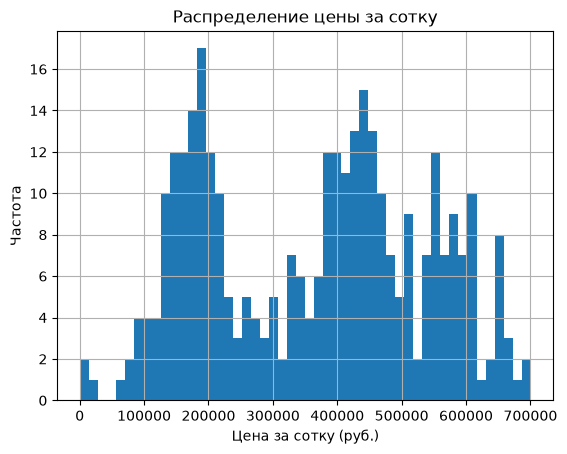

In [6]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()



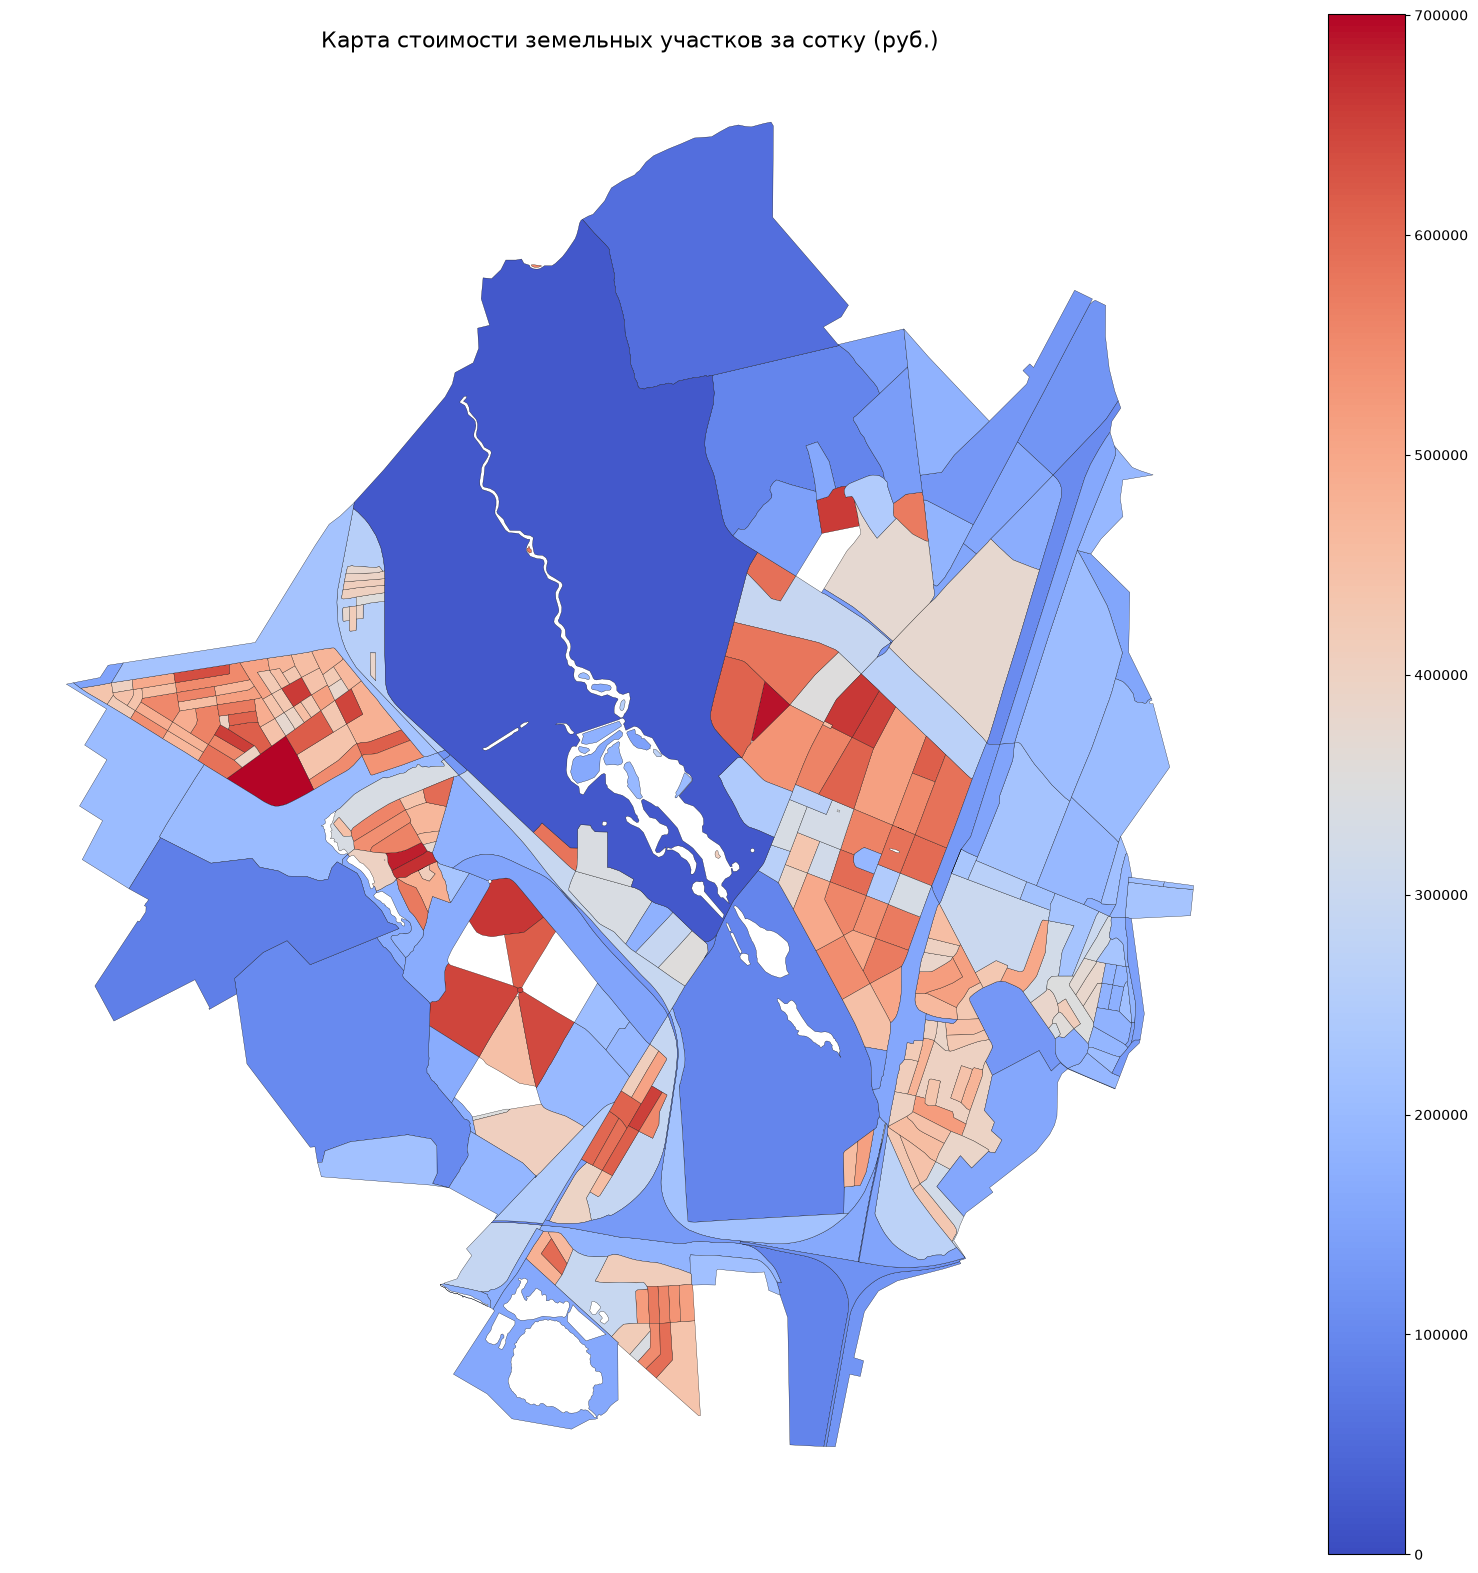

In [7]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

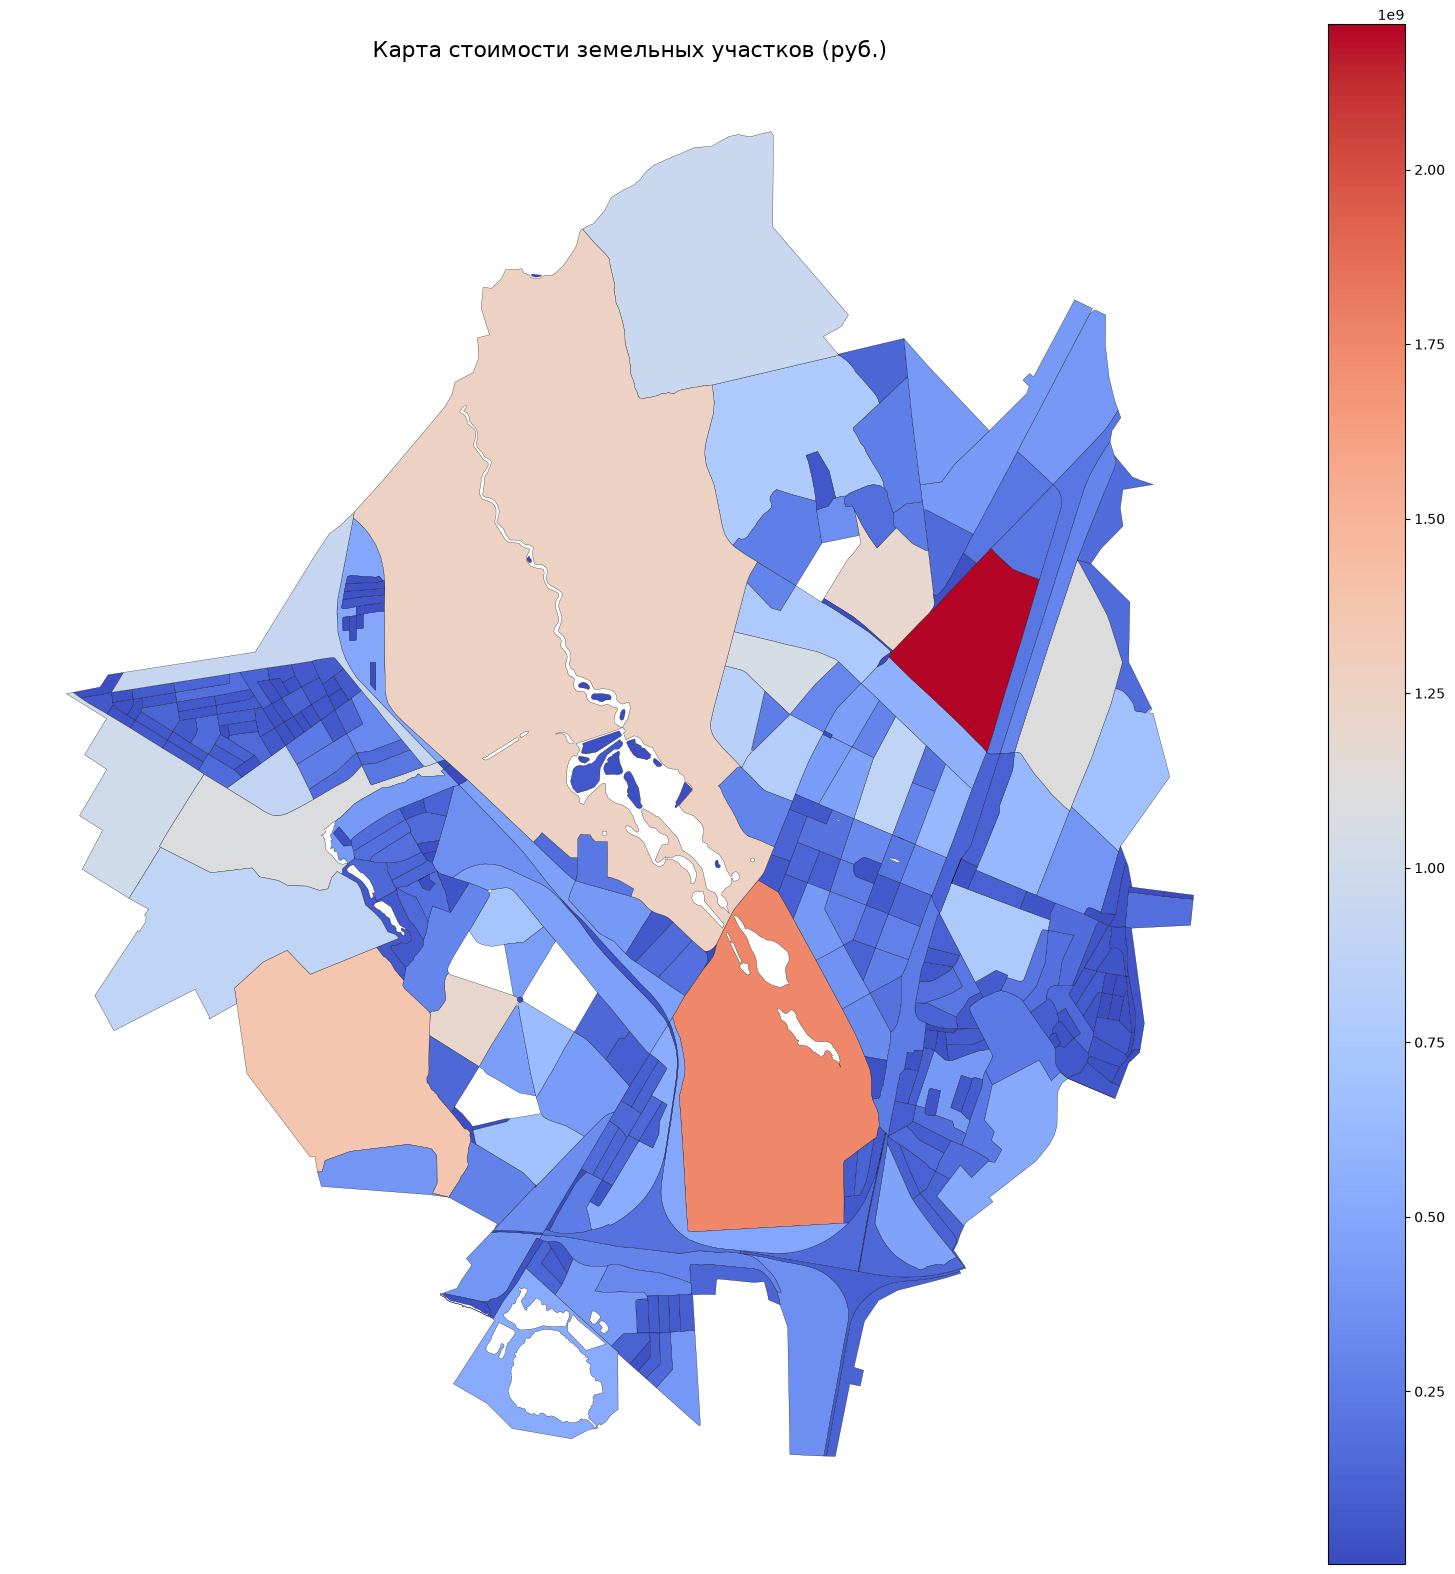

In [8]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [9]:
blocks_clean["id"] = blocks_clean.index

In [10]:
target_id = 86

/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_3933/4044864446.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


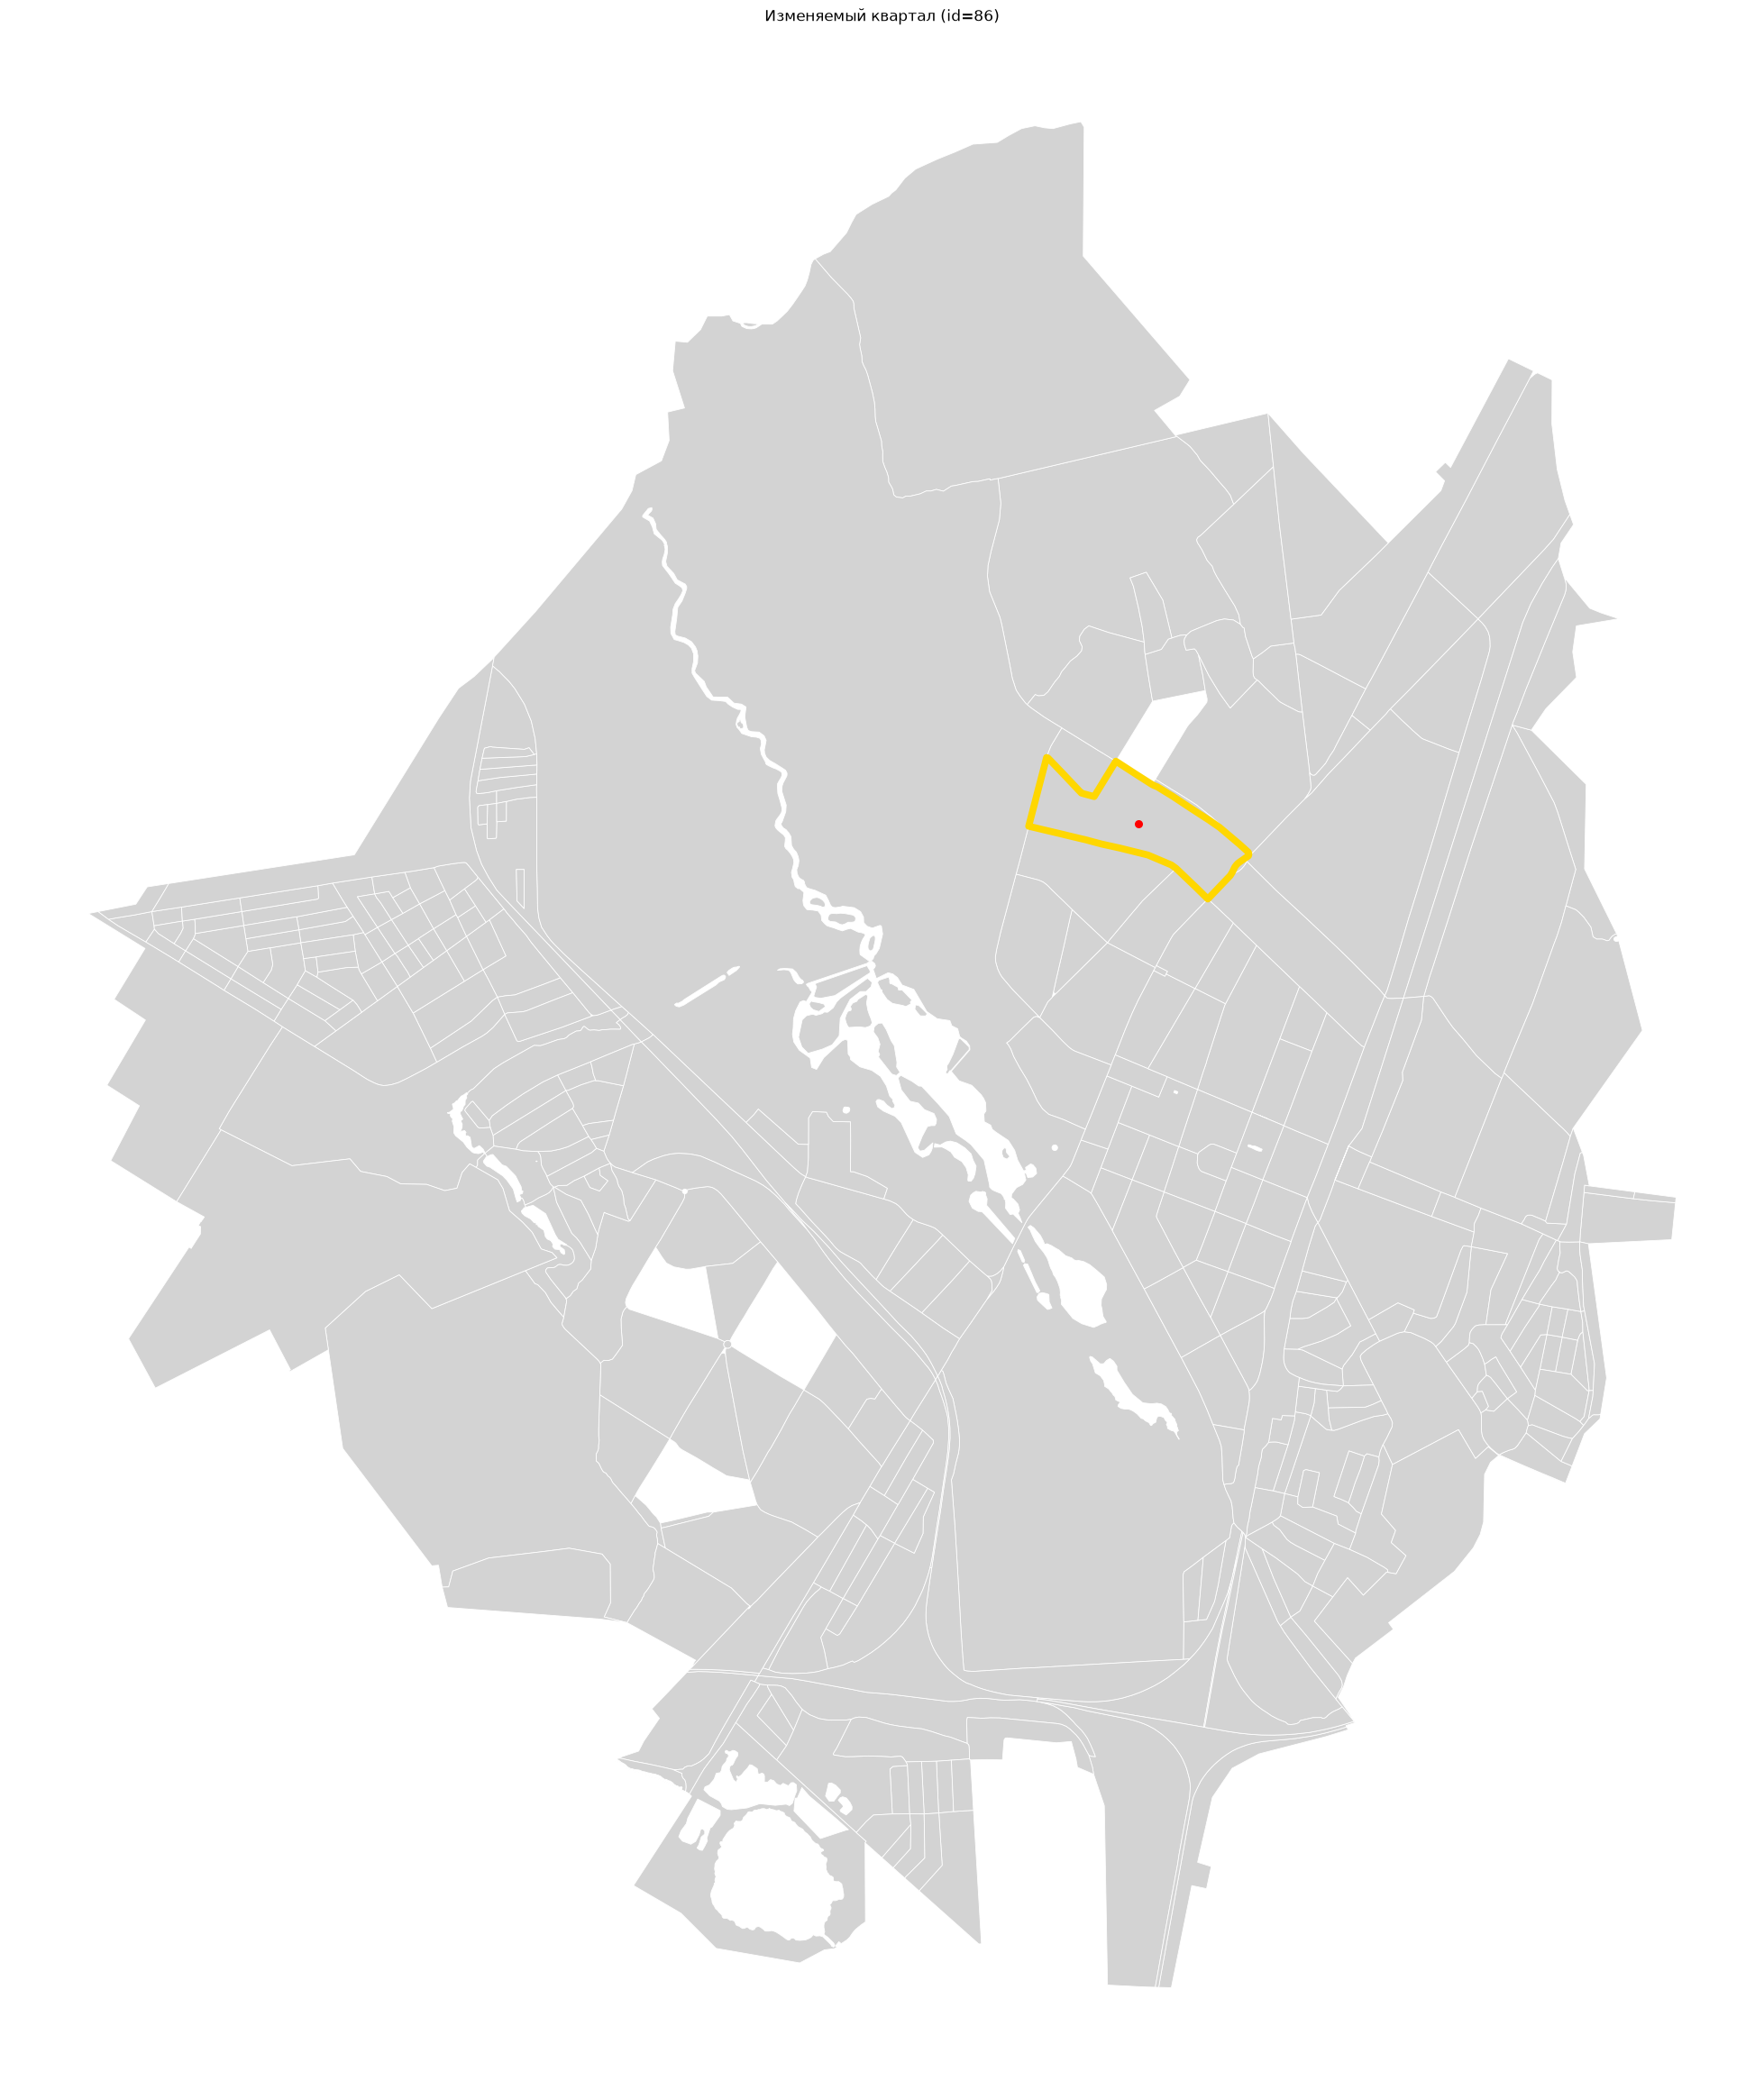

In [11]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал (id={target_id})")
ax.axis("off")
plt.show()


In [12]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

# Оптимизация района

In [13]:
site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])

constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}

from urbanomy.land_value import (
    build_pareto_front_dataframe,
    run_nsga2_with_strategic_alignment,
)
from pathlib import Path
import pandas as pd

notebook_dir = project_dir / "outputs" / "notebook"
notebook_dir.mkdir(parents=True, exist_ok=True)
optimization_log_path = notebook_dir / "optimization_log.jsonl"
pareto_front_path = notebook_dir / "pareto_front.jsonl"

prompt = """
Evaluate the presented scenario based on the criterion of balancing the interests of various land users.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
Return only valid JSON without markdown, comments, or explanations, using this exact format:
{"score": 0.0}
""".strip()

res, problem = run_nsga2_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    baseline=baseline,
    prompt=prompt,
    pop_size=4,
    n_gen=3,
    seed=42,
    verbose=True,
    save_history=True,
    log_optimization=True,
    optimization_log_path=optimization_log_path,
)

pareto_df = build_pareto_front_dataframe(res=res, problem=problem)
optimization_log_df = pd.DataFrame(problem.optimization_log)

pareto_df.to_json(pareto_front_path, orient="records", lines=True, force_ascii=False)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |        4 |      3 |             - |             -
     2 |        8 |      3 |  0.3534300260 |         ideal
     3 |       12 |      3 |  0.0624924597 |         ideal


In [14]:
pareto_df

,target_id,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,llm score
0,86,RECREATION,6.652050e+10,2.159144e+08,4.768076e+08,"{'footprint_area': 20297.073203890784, 'l': 4....",0.4
1,86,AGRICULTURE,6.647960e+10,1.750094e+08,2.132303e+09,"{'footprint_area': 19531.460508839784, 'l': 9....",0.4
2,86,AGRICULTURE,6.654708e+10,2.424911e+08,2.188903e+09,"{'footprint_area': 20111.278917849504, 'l': 9....",0.3


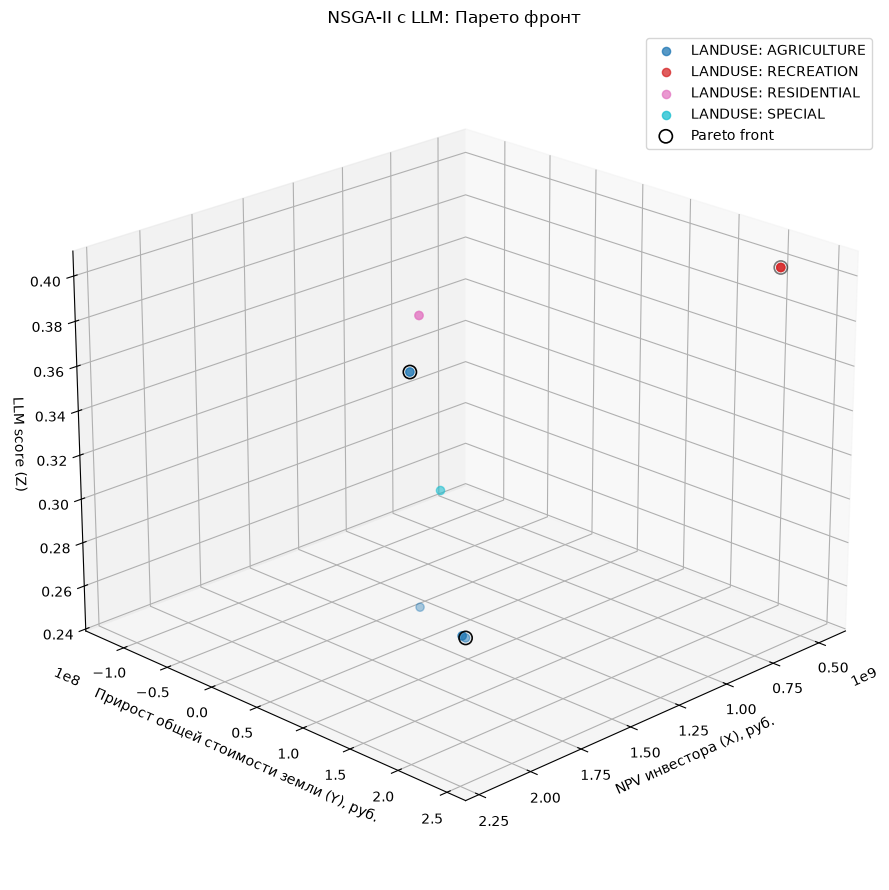

In [15]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem
result = res

baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

X_all, F_all = [], []
if getattr(result, "history", None):
    for alg in result.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.atleast_2d(np.asarray(result.X))
    F = np.atleast_2d(np.asarray(result.F))

land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
llm_score = -F[:, 2]

landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    landuse_labels.append(getattr(lu, "name", str(lu).split(".")[-1]))

landuse_labels = np.asarray(landuse_labels)
unique_lu = np.unique(landuse_labels)

cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        llm_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

F_front = np.atleast_2d(np.asarray(result.F))
pf_x = -F_front[:, 1]
pf_y = -F_front[:, 0] - baseline_land_value
pf_z = -F_front[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост общей стоимости земли (Y), руб.")
ax.set_zlabel("LLM score (Z)")
ax.set_title("NSGA-II с LLM: Парето фронт")
ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


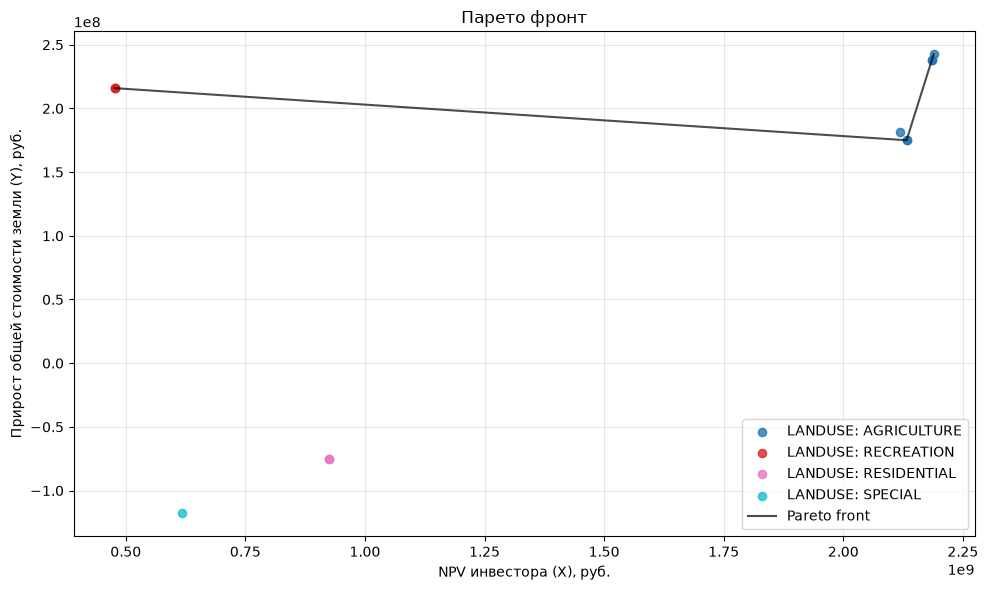

In [16]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   

# Визуализация

In [20]:
idx = np.argmin(res.F[:, 0])   # максимум land_value

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 20111.278917849504,
  'l': 9.655145981491447,
  'mxi': 0.11706680332331705,
  'residential': 0.1463335041541463,
  'business': 0.185476979386969,
  'recreation': 0.07484216895924008,
  'industrial': 0.05121105710608262,
  'transport': 0.1880973572128218,
  'special': 0.08896541058407995,
  'agriculture': 0.2650735225966603,
  'share': 0.1463335041541463,
  'land_use': <LandUse.AGRICULTURE: 'agriculture'>,
  'build_floor_area': 194177.3338263283,
  'living_area': 22731.719748892854,
  'non_living_area': 171445.61407743546,
  'population': 1136.5859874446428,
  'fsi': 0.7404255800710661,
  'gsi': 0.07668714501991312,
  'morphotype': 'high-rise soviet microdistrict'},
 'land_value_after': 66547080912.97098,
 'land_value_gain': 242491102.51008606,
 'investor_npv': 2188903395.68}

Изменение стоимости земли по всем кварталам:
 • Сумма до:    66 304 589 810 ₽
 • Сумма после: 66 547 080 913 ₽
 • Изм.  ₽:     +242 491 103 ₽
 • Изм., %:     +0.37%

Изменяемый квартал:
 • До: 741 498 772 ₽ | После: 652 653 691 ₽ | Δ: -88 845 080 ₽ | Δ%: -11.98%


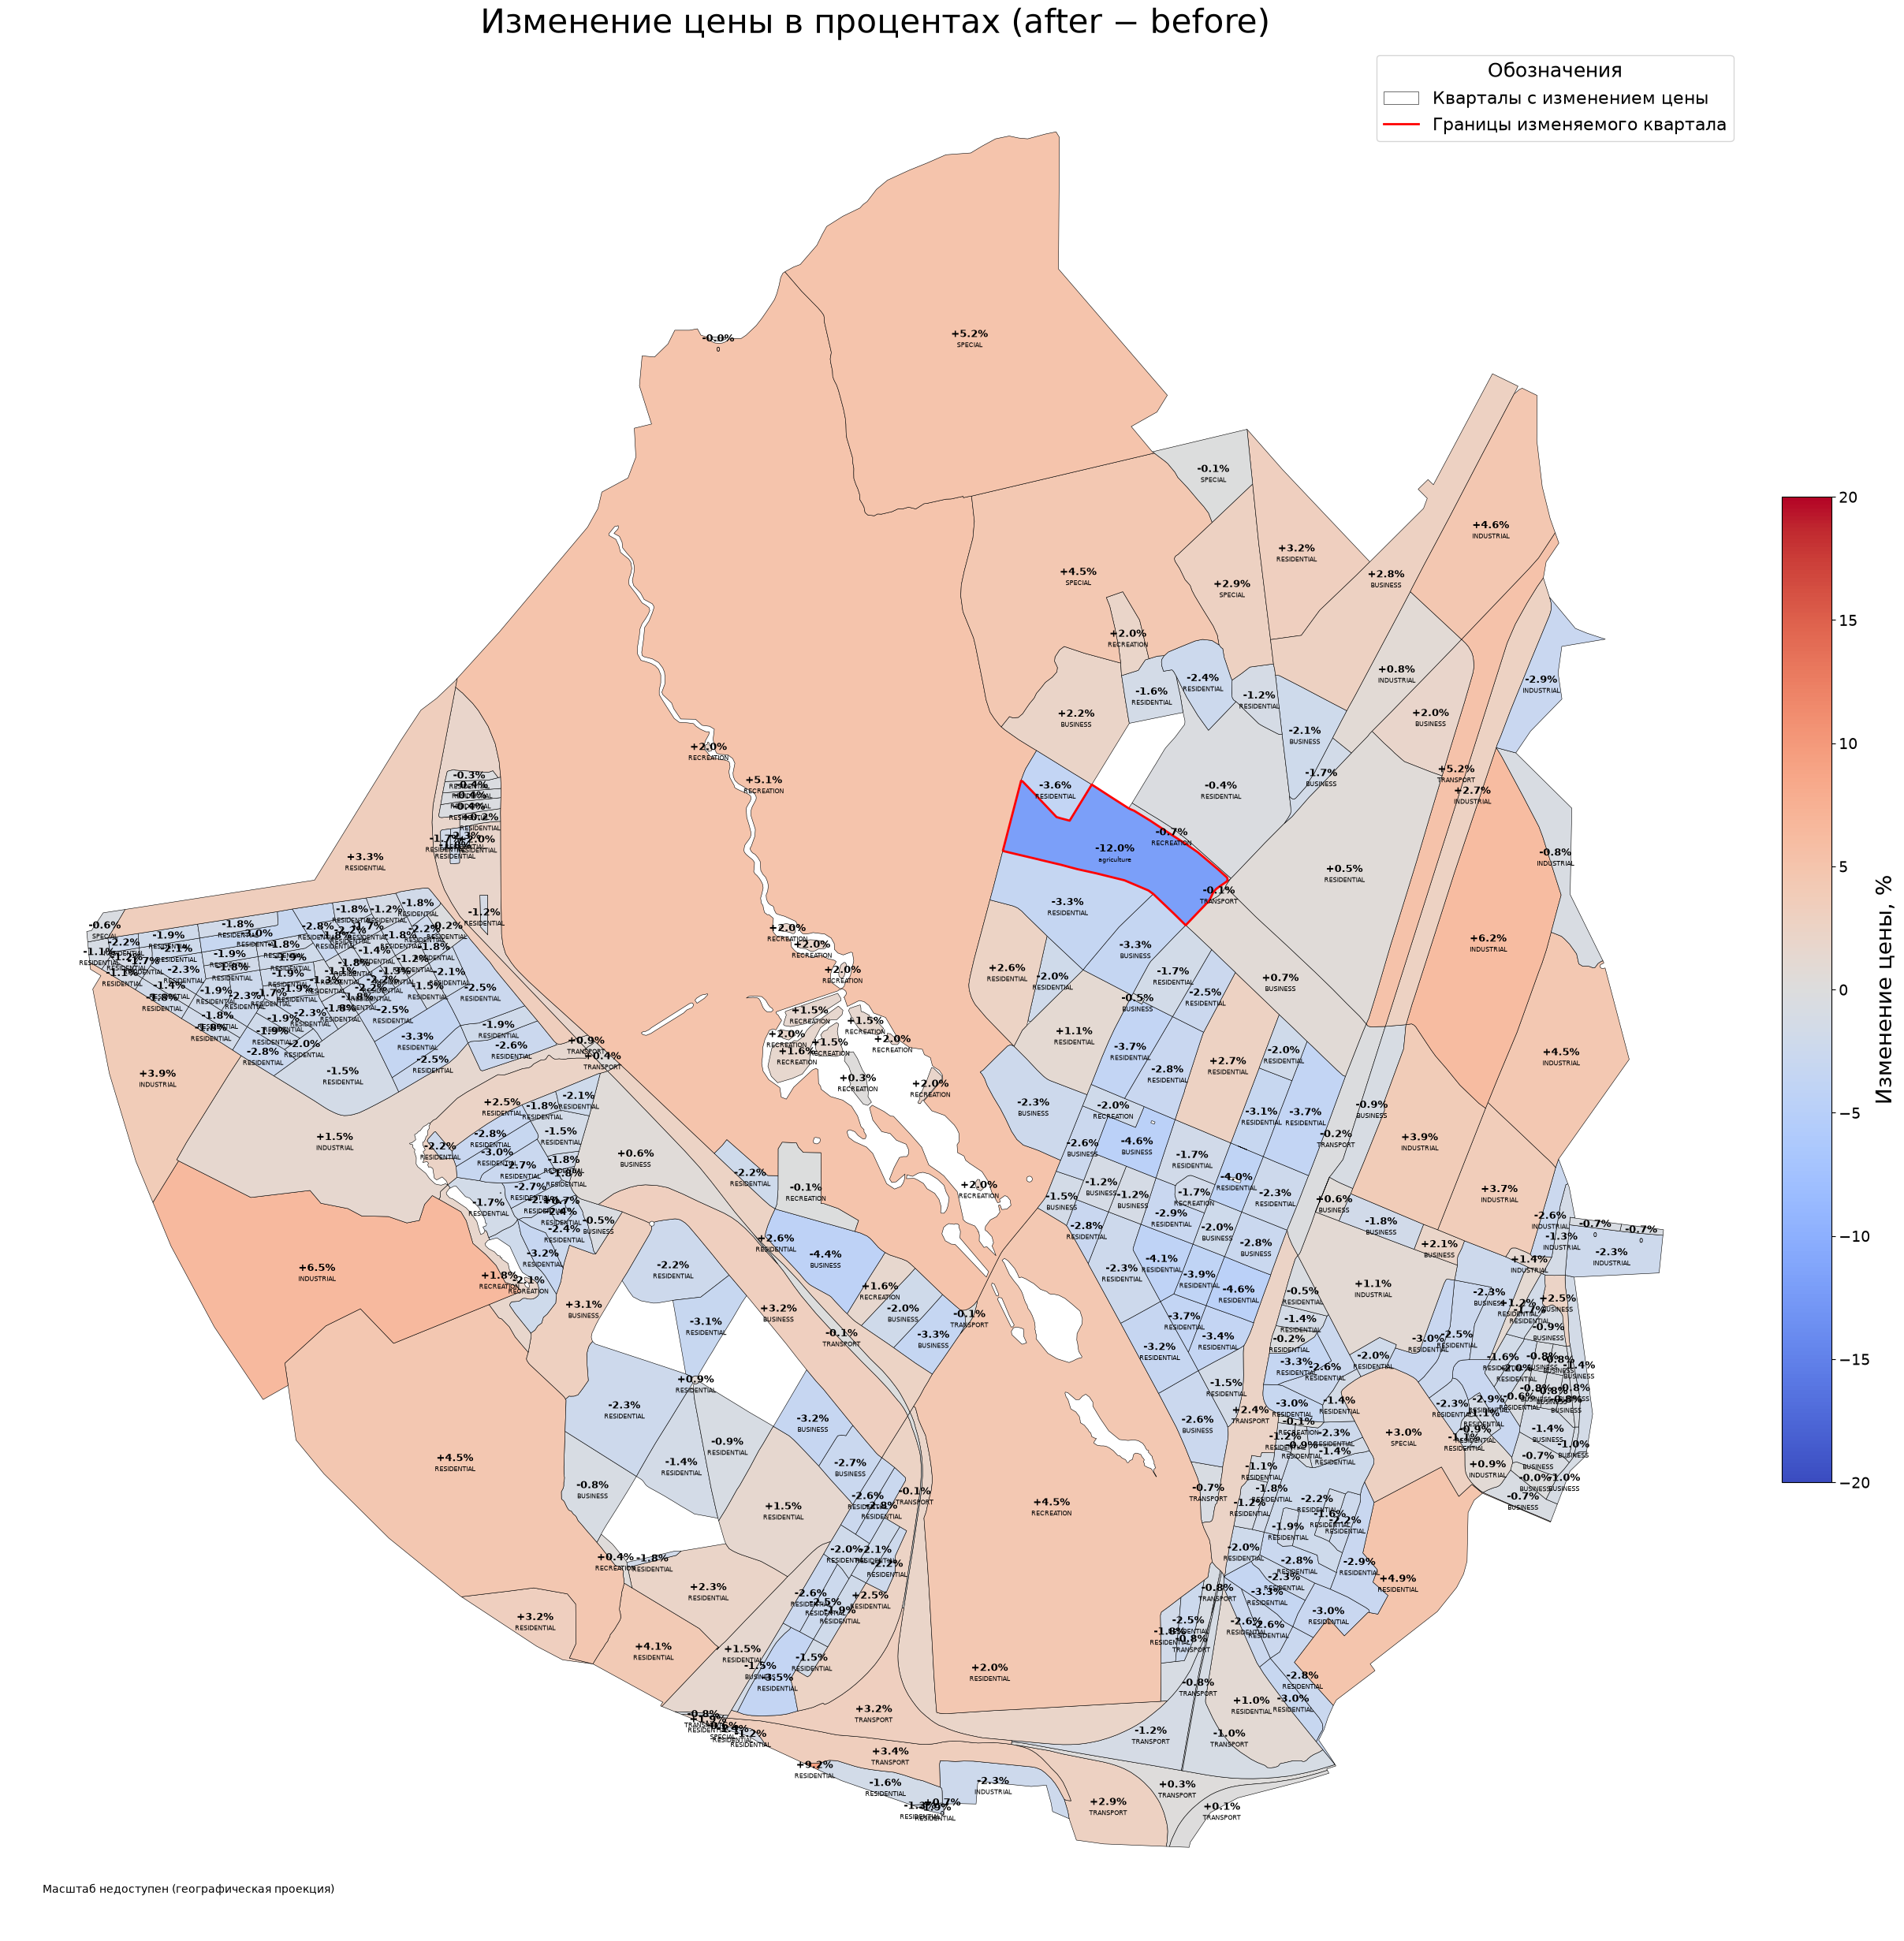

In [21]:
import numpy as np
import pandas as pd

from urbanomy.land_value import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Изменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)
